In [3]:
import shutil

import numpy as np
import drivers.receive_data_rfsoc as receiver
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime
import os



### Downloading/Saving npy file for later

In [20]:
now = datetime.now()
day = now.strftime("%Y%m%d")
s_live = now.strftime("%H%M")

device_name = "Matterhorn"
detector_name = "gN2a8-10"
laser_name = "Pulsed_Laser_Source"
mean_photon_number = 0.5
measurement_type = "Signal_analysis"


N_detected = 0.8260633261176761


In [21]:
save_dir_data = "/home/rfsoc/Documents/SNSPD_Lab_Measurements/PNR/RFSoC/" + f"{day}/" 
os.makedirs(save_dir_data, exist_ok=True)

In [22]:
HOST = "0.0.0.0"
PORT = 65432

points_per_waveform = 16
amount_of_waveforms = 10000000   # total waveforms you expect to receive

data = receiver.receive_data(
    host=HOST,
    port=PORT,
    points_per_waveform=points_per_waveform,
    amount_of_waveforms=amount_of_waveforms
)

Waiting... currently have 0/10000000 waveforms
Listening on 0.0.0.0:65432
Connected by ('10.195.175.186', 48944)
Received successfully
shape: (16000000,)
dtype: int16
first 10 values: [ 372  164   52 -124 -324 -660 -288 1148 2940 3380]
Received chunk: points=16000000, waveforms=1000000, total received=1000000
Waiting... currently have 1000000/10000000 waveforms
Listening on 0.0.0.0:65432
Connected by ('10.195.175.186', 48946)
Received successfully
shape: (16000000,)
dtype: int16
first 10 values: [ 244   84  380  444  468  556  728 2116 4492 4788]
Received chunk: points=16000000, waveforms=1000000, total received=2000000
Waiting... currently have 2000000/10000000 waveforms
Listening on 0.0.0.0:65432
Connected by ('10.195.175.186', 48948)
Received successfully
shape: (16000000,)
dtype: int16
first 10 values: [-140  412  156  180  388  -28  180 2036 3908 3520]
Received chunk: points=16000000, waveforms=1000000, total received=3000000
Waiting... currently have 3000000/10000000 waveforms
Li

In [23]:
save_path = save_dir_data + f"received_data_RAM_{mean_photon_number}.npy"
np.save(save_path, data)
print("Saved to:", save_path)

Saved to: /home/rfsoc/Documents/SNSPD_Lab_Measurements/PNR/RFSoC/20260319/received_data_RAM_0.5.npy


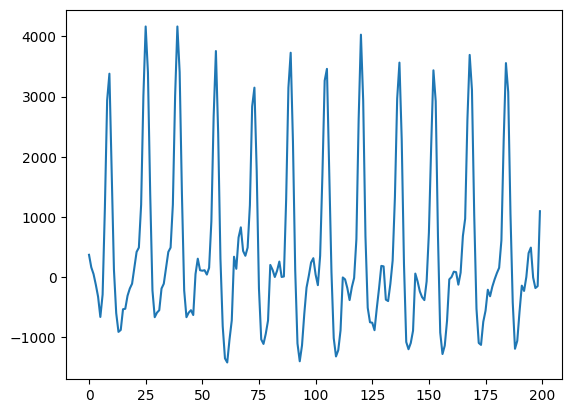

In [24]:
plt.plot(data[:200])
plt.show()


In [ ]:
x, y = pnr_analyzer.classify(data)
plt.figure(dpi=500)
plt.hist(y, bins=2000)
plt.show()